In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
dataset = pd.read_csv(r"/home/satyajit-sahoo/Downloads/bank-loan.csv")
dataset.head(4)

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,area,married,Gender
0,41,3,17,12,NaN,9.3,11.359392,5.008608,1.0,Urban,No,Female
1,27,1,10,6,31.0,17.3,1.362202,4.000798,0.0,Rural,Yes,Male
2,40,1,15,14,55.0,5.5,0.856075,2.168925,0.0,Urban,Yes,Female
3,41,1,15,14,120.0,2.9,2.658720,0.821280,0.0,NaN,Yes,Male


In [54]:
dataset.isnull().sum()

age           0
ed            0
employ        0
address       0
income        1
debtinc       0
creddebt      0
othdebt       0
default     150
area        847
married     841
Gender      841
dtype: int64

In [55]:
#  choose a field that does not contain null value or first fill the null value

/tmp/ipykernel_151323/389791176.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["employ"])


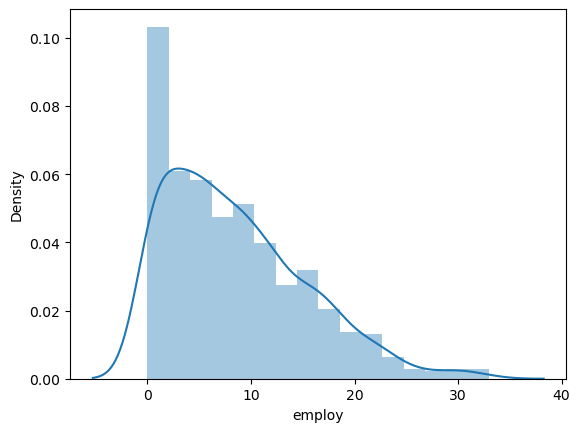

In [56]:
sns.distplot(dataset["employ"])
plt.show()

In [57]:
Q1 = dataset["employ"].quantile(0.25)
Q3 = dataset["employ"].quantile(0.75)

IQR = Q3-Q1

In [58]:
min_range = Q1 - (1.5 * IQR)
max_range = Q3 + (1.5 * IQR)

In [59]:
min_range, max_range

(-12.0, 28.0)

In [70]:
# to remove outlier

# dataset = dataset[dataset["employ"]<=max_range]

/tmp/ipykernel_151323/389791176.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["employ"])


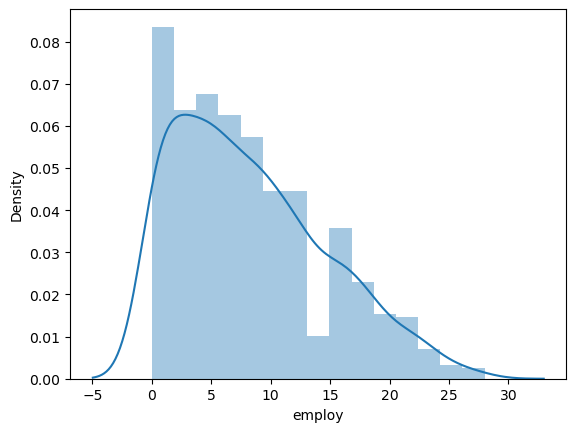

In [71]:
sns.distplot(dataset["employ"])
plt.show()

In [72]:
# to convert into normal distribution we use function transformation

In [73]:
from sklearn.preprocessing import FunctionTransformer

In [74]:
# get the log value using NUMPY
# using log1p because it does not give any invalid value or infinite value as a result, if there is a value '0' in our dataset using 
# logBASE(10) or logBASE(e) takes you to an infinite value and does not provide a desired value for our calculation.

ft = FunctionTransformer(func=np.log1p)
ft.fit(dataset[["employ"]])

FunctionTransformer(func=<ufunc 'log1p'>)

In [75]:
dataset["employ_transform_data"] = ft.transform(dataset[["employ"]])

/tmp/ipykernel_151323/3361139988.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["employ"])
/tmp/ipykernel_151323/3361139988.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["employ_transform_data"])


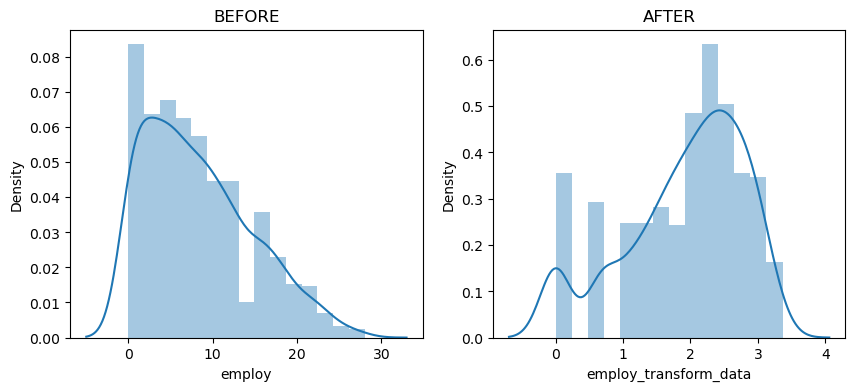

In [76]:
plt.figure(figsize=(10, 4))

# to show 2 different. plot we r using subplot plt.subplot(row, column, plot position)
plt.subplot(1, 2, 1)
sns.distplot(dataset["employ"])
plt.title("BEFORE")

plt.subplot(1, 2, 2)
sns.distplot(dataset["employ_transform_data"])
plt.title("AFTER")

plt.show()

In [77]:
# when to use - 

# When you think there is some important data present in the outlier, which is very important for future calculations, then we can use 
# Function-Transformation technique to transform a function without removing outliers.

In [78]:
# we can use other functions like x**2 in function transformer

ft1 = FunctionTransformer(func=lambda x : x**2)
ft1.fit(dataset[["employ"]])
dataset["employ_transform_data2"] = ft1.transform(dataset[["employ"]])

/tmp/ipykernel_151323/3091565088.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["employ"])
/tmp/ipykernel_151323/3091565088.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["employ_transform_data2"])


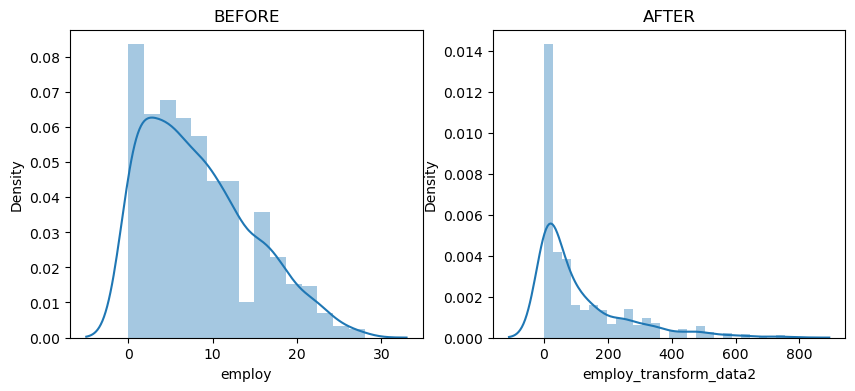

In [79]:
plt.figure(figsize=(10, 4))

# to show 2 different. plot we r using subplot plt.subplot(row, column, plot position)
plt.subplot(1, 2, 1)
sns.distplot(dataset["employ"])
plt.title("BEFORE")

plt.subplot(1, 2, 2)
sns.distplot(dataset["employ_transform_data2"])
plt.title("AFTER")

plt.show()